# VLM Assignment

| Part | Topic |
|------|-------|
| **Part 1** | small VLM 구조 이해에 관한 코딩 문제 |
| **Part 2** | small VLM에서 사용한 HuggingFace Transformer에 관한 코딩 문제 |
| **Part 3** | small VLM 기반 Image Captioning task 관련 '입력 형식 + prompt 변환 + 출력 관찰'에 관한 문제 |


## 패키지 설치 및 공통 Import

In [ ]:
# !pip install torch torchvision transformers datasets Pillow

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {'cuda' if torch.cuda.is_available() else 'cpu'}")


PyTorch version : 2.12.0.dev20260407+cu128
Device          : cuda


## 강의 베이스 코드

In [173]:
class MiniVisionEncoder(nn.Module):
    def __init__(self, image_size=224, image_channels=3, vision_dim=32, patch_size=16):
        super().__init__()
        self.patch_embed = nn.Conv2d(
            in_channels=image_channels,
            out_channels=vision_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )
        num_patches = (image_size // patch_size) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, vision_dim))
        layer = nn.TransformerEncoderLayer(
            d_model=vision_dim, nhead=4, batch_first=True, dropout=0.0, activation='gelu',
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=1)
        self.norm = nn.LayerNorm(vision_dim)

    def forward(self, pixel_values):
        x = self.patch_embed(pixel_values)                   # [B, D_vision, H/P, W/P]
        image_features = x.flatten(2).transpose(1, 2)        # [B, N_patches, D_vision]
        image_features = image_features + self.pos_embed
        image_features = self.transformer(image_features)
        image_features = self.norm(image_features)
        return image_features                                 # [B, N_patches, D_vision]


class MiniProjector(nn.Module):
    def __init__(self, vision_dim=32, text_dim=64):
        super().__init__()
        self.proj = nn.Linear(vision_dim, text_dim)

    def forward(self, image_features):
        return self.proj(image_features)                      # [B, N_patches, D_text]


class MiniTextDecoder(nn.Module):
    def __init__(self, vocab_size=1000, text_dim=64):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, text_dim)
        layer = nn.TransformerEncoderLayer(
            d_model=text_dim, nhead=4, batch_first=True, dropout=0.0, activation='gelu',
        )
        self.decoder = nn.TransformerEncoder(layer, num_layers=1)
        self.lm_head = nn.Linear(text_dim, vocab_size)

    def forward(self, image_embeds, input_ids):
        text_embeds   = self.token_embed(input_ids)
        inputs_embeds = torch.cat([image_embeds, text_embeds], dim=1)
        seq_len       = inputs_embeds.size(1)
        causal_mask   = nn.Transformer.generate_square_subsequent_mask(seq_len).to(inputs_embeds.device)
        hidden_states = self.decoder(inputs_embeds, mask=causal_mask, is_causal=True)
        logits        = self.lm_head(hidden_states)
        return logits, inputs_embeds


class SimpleMiniVLM(nn.Module):
    def __init__(self, image_size=224, vocab_size=1000, vision_dim=32, text_dim=64, patch_size=16):
        super().__init__()
        self.vision_encoder = MiniVisionEncoder(image_size=image_size, vision_dim=vision_dim, patch_size=patch_size)
        self.projector      = MiniProjector(vision_dim=vision_dim, text_dim=text_dim)
        self.text_decoder   = MiniTextDecoder(vocab_size=vocab_size, text_dim=text_dim)

    def forward(self, pixel_values, input_ids):
        image_features = self.vision_encoder(pixel_values)
        image_embeds   = self.projector(image_features)
        logits, inputs_embeds = self.text_decoder(image_embeds, input_ids)
        return logits, {"image_features": image_features,
                        "image_embeds":   image_embeds,
                        "inputs_embeds":  inputs_embeds}

# 공통 하이퍼파라미터
B, H, W, L_TEXT       = 2, 224, 224, 8
VOCAB, D_VISION, D_TEXT, PATCH = 1000, 32, 64, 16
N_IMG = (H // PATCH) ** 2   # 196

torch.manual_seed(0)
pixel_values = torch.randn(B, 3, H, W)
input_ids    = torch.randint(0, VOCAB, (B, L_TEXT))


---
# Part 1

### 과제 (1): image 영역의 시작과 끝을 구분하기 위해  [IMG_START], [IMG_END] 두 개 token 넣기

| 기존 | 변경 |
|------|------|
| `image_tokens + text_tokens` | `[IMG_START] + image_tokens + [IMG_END] + text_tokens` |

- decoder input shape 출력
- sequence length 증가분 출력
- 첫번째/마지막 image token 출력
- token별 위치 출력


In [174]:
class VLM_with_IMG_boundary(nn.Module):
    def __init__(self, image_size=224, vocab_size=1000, vision_dim=32, text_dim=64, patch_size=16):
        super().__init__()
        # vocab 2개 확장: [IMG_START]=1000, [IMG_END]=1001
        self.extended_vocab_size = vocab_size + 2
        self.img_start_id = vocab_size
        self.img_end_id   = vocab_size + 1

        self.vision_encoder = MiniVisionEncoder(image_size=image_size, vision_dim=vision_dim, patch_size=patch_size)
        self.projector      = MiniProjector(vision_dim=vision_dim, text_dim=text_dim)
        self.token_embed    = nn.Embedding(self.extended_vocab_size, text_dim)

        layer = nn.TransformerEncoderLayer(d_model=text_dim, nhead=4, batch_first=True, dropout=0.0, activation='gelu')
        self.decoder = nn.TransformerEncoder(layer, num_layers=1)
        self.lm_head = nn.Linear(text_dim, self.extended_vocab_size)

    def forward(self, pixel_values, input_ids):
        B = pixel_values.size(0)

        # 1. Vision Encoder + Projector
        image_embeds = self.projector(self.vision_encoder(pixel_values))  # [B, N_img, D_text]

        # 2. [IMG_START] / [IMG_END] 임베딩 생성
        img_start_emb = self.token_embed(
            torch.full((B, 1), self.img_start_id, dtype=torch.long, device=pixel_values.device))
        img_end_emb   = self.token_embed(
            torch.full((B, 1), self.img_end_id,   dtype=torch.long, device=pixel_values.device))

        # 3. 텍스트 임베딩
        text_embeds = self.token_embed(input_ids)

        # 4. 시퀀스 구성: [IMG_START] + image_tokens + [IMG_END] + text_tokens
        inputs_embeds = torch.cat([img_start_emb, image_embeds, img_end_emb, text_embeds], dim=1)

        # 5. Decoder
        seq_len     = inputs_embeds.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(inputs_embeds.device)
        logits      = self.lm_head(self.decoder(inputs_embeds, mask=causal_mask, is_causal=True))

        return logits, inputs_embeds


### 과제 (1) 제출 결과 출력

In [176]:
model_1 = VLM_with_IMG_boundary(image_size=H, vocab_size=VOCAB, vision_dim=D_VISION, text_dim=D_TEXT, patch_size=PATCH)
model_1.eval()

with torch.no_grad():
    logits_1, inputs_embeds_1 = model_1(pixel_values, input_ids)

original_seq = N_IMG + L_TEXT          # 204
new_seq      = 1 + N_IMG + 1 + L_TEXT  # 206

print(" decoder input shape :", tuple(inputs_embeds_1.shape))

print(f"\n sequence length 증가분")
print(f"  기존 : {original_seq}  (N_img={N_IMG} + L_text={L_TEXT})")
print(f"  변경 : {new_seq}  ([IMG_START]=1 + N_img={N_IMG} + [IMG_END]=1 + L_text={L_TEXT})")
print(f"  증가 : +{new_seq - original_seq}")

print(f"\n 첫 번째 image token  위치 : 1")
print(f"   마지막 image token 위치 : {N_IMG}")
print(f"\n 첫 번째 image token 값 (앞 5 dim) :")
print(f"   {inputs_embeds_1[0, 1, :5].tolist()}")
print(f"\n 마지막 image token 값 (앞 5 dim) :")
print(f"   {inputs_embeds_1[0, N_IMG, :5].tolist()}")

print(f"\n token별 위치")
print(f"  0 : IMG_START")
print(f"  1 ~ {N_IMG} : image")
print(f"  {N_IMG+1} : IMG_END")
print(f"  {N_IMG+2} ~ {new_seq-1} : text")


 decoder input shape : (2, 206, 64)

 sequence length 증가분
  기존 : 204  (N_img=196 + L_text=8)
  변경 : 206  ([IMG_START]=1 + N_img=196 + [IMG_END]=1 + L_text=8)
  증가 : +2

 첫 번째 image token  위치 : 1
   마지막 image token 위치 : 196

 첫 번째 image token 값 (앞 5 dim) :
   [-0.7072800993919373, -0.23839086294174194, 0.3656580448150635, 0.7784571647644043, 0.8137652277946472]

 마지막 image token 값 (앞 5 dim) :
   [0.26839232444763184, -0.1815468668937683, 1.2020808458328247, -0.4080587923526764, 0.7161170244216919]

 token별 위치
  0 : IMG_START
  1 ~ 196 : image
  197 : IMG_END
  198 ~ 205 : text


---
## 과제 (2): text 없이 image token만 decoder에 넣기
| 기존 | 변경 |
|------|------|
| `image_tokens + text_tokens` | `image_tokens only` |

- decoder input shape 출력
- image token 개수 출력
- text token 개수 출력
- sequence length 출력
- token별 위치 출력

In [178]:
class VLM_image_only(nn.Module):
    def __init__(self, image_size=224, vocab_size=1000, vision_dim=32, text_dim=64, patch_size=16):
        super().__init__()
        self.vision_encoder = MiniVisionEncoder(image_size=image_size, vision_dim=vision_dim, patch_size=patch_size)
        self.projector      = MiniProjector(vision_dim=vision_dim, text_dim=text_dim)

        layer = nn.TransformerEncoderLayer(d_model=text_dim, nhead=4, batch_first=True, dropout=0.0, activation='gelu')
        self.decoder = nn.TransformerEncoder(layer, num_layers=1)
        self.lm_head = nn.Linear(text_dim, vocab_size)

    def forward(self, pixel_values):
        image_embeds  = self.projector(self.vision_encoder(pixel_values))  # [B, N_img, D_text]
        inputs_embeds = image_embeds                                        # text 없음

        seq_len     = inputs_embeds.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(inputs_embeds.device)
        logits      = self.lm_head(self.decoder(inputs_embeds, mask=causal_mask, is_causal=True))
        return logits, inputs_embeds


### 과제 (2) 제출 결과 출력

In [177]:
model_2 = VLM_image_only(image_size=H, vocab_size=VOCAB, vision_dim=D_VISION, text_dim=D_TEXT, patch_size=PATCH)
model_2.eval()

with torch.no_grad():
    logits_2, inputs_embeds_2 = model_2(pixel_values)

print(" decoder input shape :", tuple(inputs_embeds_2.shape))

print(f"\n image token 개수 : {N_IMG}")
print(f" text  token 개수 : 0  (text 없음)")
print(f" sequence length  : {N_IMG}  (image tokens only)")

print(f"\n token별 위치")
print(f"  0 ~ {N_IMG-1} : image")
print(f"  (text tokens 없음)")


 decoder input shape : (2, 196, 64)

 image token 개수 : 196
 text  token 개수 : 0  (text 없음)
 sequence length  : 196  (image tokens only)

 token별 위치
  0 ~ 195 : image
  (text tokens 없음)


---
## 과제 (3): [IMG_SUM] + projected_image_tokens + text_tokens 형태로 decoder input 구성

| 기존 | 변경 |
|------|------|
| `projected_image_tokens + text_tokens` | `[IMG_SUM] + projected_image_tokens + text_tokens` |

- decoder input shape 출력
- 첫 번째 token 값 출력
- parameter 개수 증가에 관한 정보 출력
- IMG_SUM 역할 설명
- token별 위치 출력


In [179]:
class VLM_with_IMG_SUM(nn.Module):
    def __init__(self, image_size=224, vocab_size=1000, vision_dim=32, text_dim=64, patch_size=16):
        super().__init__()
        self.vision_encoder = MiniVisionEncoder(image_size=image_size, vision_dim=vision_dim, patch_size=patch_size)
        self.projector      = MiniProjector(vision_dim=vision_dim, text_dim=text_dim)

        # learnable special token: 처음엔 랜덤값, 학습으로 의미 있는 벡터로 수렴
        self.img_sum_token = nn.Parameter(torch.randn(1, 1, text_dim))

        self.token_embed = nn.Embedding(vocab_size, text_dim)
        layer = nn.TransformerEncoderLayer(d_model=text_dim, nhead=4, batch_first=True, dropout=0.0, activation='gelu')
        self.decoder = nn.TransformerEncoder(layer, num_layers=1)
        self.lm_head = nn.Linear(text_dim, vocab_size)

    def forward(self, pixel_values, input_ids):
        B = pixel_values.size(0)

        image_embeds = self.projector(self.vision_encoder(pixel_values))   # [B, N_img, D_text]
        img_sum      = self.img_sum_token.expand(B, -1, -1)                # [B, 1, D_text]
        text_embeds  = self.token_embed(input_ids)                         # [B, L_text, D_text]

        # [IMG_SUM] + image_tokens + text_tokens
        inputs_embeds = torch.cat([img_sum, image_embeds, text_embeds], dim=1)

        seq_len     = inputs_embeds.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(inputs_embeds.device)
        logits      = self.lm_head(self.decoder(inputs_embeds, mask=causal_mask, is_causal=True))
        return logits, inputs_embeds

def count_params(m):
    return sum(p.numel() for p in m.parameters())


### 과제 (3) 제출 결과 출력

In [180]:
model_3 = VLM_with_IMG_SUM(
    image_size=H, vocab_size=VOCAB, vision_dim=D_VISION, text_dim=D_TEXT, patch_size=PATCH
)
model_3.eval()

with torch.no_grad():
    logits_3, inputs_embeds_3 = model_3(pixel_values, input_ids)

new_seq = 1 + N_IMG + L_TEXT  # 205

print("decoder input shape :", tuple(inputs_embeds_3.shape))

print(f"\n첫 번째 token 값")
print(f" inputs_embeds_3[0, 0, :5] = {inputs_embeds_3[0, 0, :5].tolist()}")

total_params     = sum(p.numel() for p in model_3.parameters())
trainable_params = sum(p.numel() for p in model_3.parameters() if p.requires_grad)
img_sum_params   = model_3.img_sum_token.numel()

print(f"\nparameter 수 정보")
print(f"  전체 파라미터    : {total_params:,}")
print(f"  학습 가능 파라미터: {trainable_params:,}")
print(f"  [IMG_SUM] 증가분 : +{img_sum_params}개  (1 x D_text={D_TEXT})")

print(f"\n[IMG_SUM] 역할")
print("  - self-attention을 통해 196개 image patch 정보를 하나의 벡터로 집약")
print("  - ViT의 [CLS] 토큰과 동일한 개념")
print("  - 학습 중 gradient로 업데이트되어 이미지 전체 의미를 압축하도록 수렴")
print("  - decoder가 개별 patch 대신 이 토큰 하나로 이미지 맥락을 파악 가능")

print(f"\ntoken별 위치")
print(f"  0 : [IMG_SUM]")
print(f"  1 ~ {N_IMG} : image")
print(f"  {N_IMG+1} ~ {new_seq-1} : text tokens")

decoder input shape : (2, 205, 64)

첫 번째 token 값
 inputs_embeds_3[0, 0, :5] = [0.3880053162574768, 0.6184877753257751, -0.878499448299408, -2.455150604248047, 0.8537982106208801]

parameter 수 정보
  전체 파라미터    : 580,776
  학습 가능 파라미터: 580,776
  [IMG_SUM] 증가분 : +64개  (1 x D_text=64)

[IMG_SUM] 역할
  - self-attention을 통해 196개 image patch 정보를 하나의 벡터로 집약
  - ViT의 [CLS] 토큰과 동일한 개념
  - 학습 중 gradient로 업데이트되어 이미지 전체 의미를 압축하도록 수렴
  - decoder가 개별 patch 대신 이 토큰 하나로 이미지 맥락을 파악 가능

token별 위치
  0 : [IMG_SUM]
  1 ~ 196 : image
  197 ~ 204 : text tokens


---
### 과제 (4) : Multi-view Image Embedding Concatenation

[목표]
여러 각도에서 찍은 이미지를 그냥 "이미지 토큰을 이어붙여서" 하나의 입력으로 만드는 것
(진짜 "fusion learning" 아님, "token concatenation 실습")

#### 데이터 준비: 로컬 이미지 사용
동일한 객체를 front / side / top 3가지 각도에서 촬영한 이미지를 사용합니다.
각 이미지는 `~/project/VLM_2/images/` 폴더의 `front.jpg`, `side.jpg`, `top.jpg`에서 로드합니다.

수집된 이미지 수 : 3장
  front view : (4032, 3024)
  side view : (4032, 3024)
  top view : (4032, 3024)


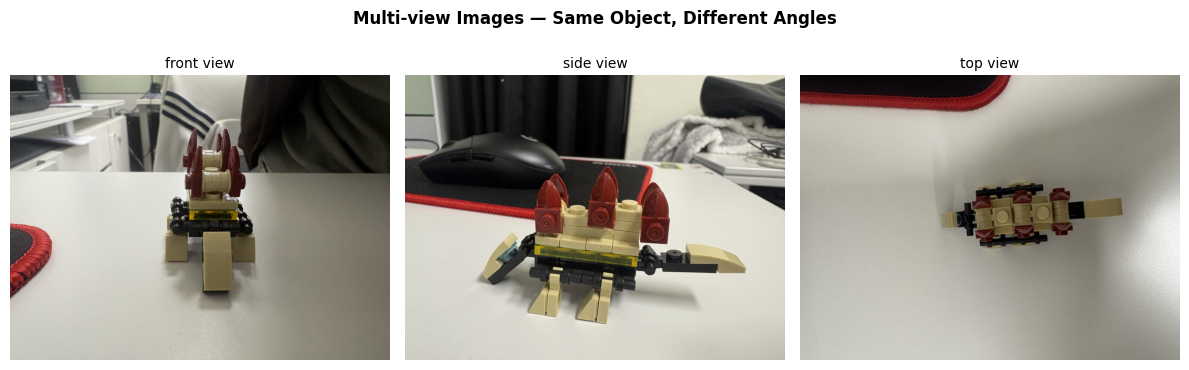

In [183]:
from PIL import Image
from pathlib import Path

IMAGE_DIR = Path.home() / "project" / "VLM_2" / "images"

collected = [
    Image.open(IMAGE_DIR / "front.jpg").convert("RGB"),
    Image.open(IMAGE_DIR / "side.jpg").convert("RGB"),
    Image.open(IMAGE_DIR / "top.jpg").convert("RGB"),
]
view_names = ["front view", "side view", "top view"]

print(f"수집된 이미지 수 : {len(collected)}장")
for name, img in zip(view_names, collected):
    print(f"  {name} : {img.size}")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, name in zip(axes, collected, view_names):
    ax.imshow(img)
    ax.set_title(name, fontsize=10)
    ax.axis("off")
plt.suptitle("Multi-view Images — Same Object, Different Angles", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [184]:
# PIL Image -> Mini VLM 입력 tensor로 변환
to_tensor = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),                     # [3, 224, 224], 값 범위 [0, 1]
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),  # ImageNet 정규화 (강의 SmolVLM 전처리와 동일 방식)
])

# 각 이미지를 [1, 3, 224, 224] 텐서로 변환 (B=1)
view_tensors = [to_tensor(img).unsqueeze(0) for img in collected]

# view 이름 정의 (동일 객체의 다른 각도로 간주)
view_names = ["front view", "side view", "top view"]

print("변환된 tensor shape:")
for name, t in zip(view_names, view_tensors):
    print(f"  {name} : {tuple(t.shape)}")


변환된 tensor shape:
  front view : (1, 3, 224, 224)
  side view : (1, 3, 224, 224)
  top view : (1, 3, 224, 224)


## MultiViewVLM 모델 정의

In [187]:
class MultiViewVLM(nn.Module):
    def __init__(self, image_size=224, vocab_size=1000, vision_dim=32, text_dim=64, patch_size=16):
        super().__init__()
        self.vision_encoder = MiniVisionEncoder(image_size=image_size, vision_dim=vision_dim, patch_size=patch_size)
        self.projector      = MiniProjector(vision_dim=vision_dim, text_dim=text_dim)
        self.token_embed    = nn.Embedding(vocab_size, text_dim)
        self.patch_size     = patch_size
        self.image_size     = image_size

        layer = nn.TransformerEncoderLayer(d_model=text_dim, nhead=4, batch_first=True, dropout=0.0, activation='gelu')
        self.decoder = nn.TransformerEncoder(layer, num_layers=1)
        self.lm_head = nn.Linear(text_dim, vocab_size)

    @property
    def n_patches(self):
        return (self.image_size // self.patch_size) ** 2  # 196

    def encode_images(self, images: list[torch.Tensor]) -> torch.Tensor:
        """각 view를 encode한 뒤 sequence 방향(dim=1)으로 concat합니다."""
        embeds = [self.projector(self.vision_encoder(img)) for img in images]
        return torch.cat(embeds, dim=1)   # [B, n_views * N_img, D_text]

    def forward(self, images: list[torch.Tensor], input_ids: torch.Tensor):
        multi_img_emb = self.encode_images(images)             # [B, n*N_img, D_text]
        text_embeds   = self.token_embed(input_ids)            # [B, L_text, D_text]
        inputs_embeds = torch.cat([multi_img_emb, text_embeds], dim=1)

        seq_len     = inputs_embeds.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(inputs_embeds.device)
        logits      = self.lm_head(self.decoder(inputs_embeds, mask=causal_mask, is_causal=True))
        return logits, inputs_embeds, multi_img_emb

torch.manual_seed(42)
B_mv      = 1
input_ids_mv = torch.randint(0, VOCAB, (B_mv, L_TEXT))

mv_model = MultiViewVLM(image_size=H, vocab_size=VOCAB, vision_dim=D_VISION, text_dim=D_TEXT, patch_size=PATCH)
mv_model.eval()


MultiViewVLM(
  (vision_encoder): MiniVisionEncoder(
    (patch_embed): Conv2d(3, 32, kernel_size=(16, 16), stride=(16, 16))
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
          )
          (linear1): Linear(in_features=32, out_features=2048, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (linear2): Linear(in_features=2048, out_features=32, bias=True)
          (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
          (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
          (dropout1): Dropout(p=0.0, inplace=False)
          (dropout2): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (projector): MiniProjector(
    (proj): 

---
### 과제 (4.1): 동일 이미지에 대해서 camera view가 다른 2-3장 이미지를 embedding concat하세요.

- 이미지 개수 출력
- embedding shape 출력
- 이미지 개수에 따른 sequence 길이 출력
- multi-image 입력 caption 1개 출력

In [191]:
print("4.1")

for n_views in [2, 3]:
    views = view_tensors[:n_views]

    with torch.no_grad():
        logits, inputs_embeds, multi_img_emb = mv_model(views, input_ids_mv)

    img_seq   = n_views * N_IMG
    total_seq = img_seq + L_TEXT

    print(f"\n이미지 개수 : {n_views}장  ({', '.join(view_names[:n_views])})")
    print(f"embedding shape : {tuple(multi_img_emb.shape)}")
    print(f"decoder input shape : {tuple(inputs_embeds.shape)}")
    print(f"sequence 길이 = {n_views}x{N_IMG} + {L_TEXT}(text) = {total_seq}")

print(f"\n이미지 개수별 sequence 길이 비교")
print(f"  1장 : 1x{N_IMG} + {L_TEXT} = {1*N_IMG+L_TEXT}")
print(f"  2장 : 2x{N_IMG} + {L_TEXT} = {2*N_IMG+L_TEXT}")
print(f"  3장 : 3x{N_IMG} + {L_TEXT} = {3*N_IMG+L_TEXT}")

def greedy_caption(model, views, input_ids, max_new_tokens=10):
    generated = input_ids.clone()
    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits, _, _ = model(views, generated)
        next_token = logits[:, -1, :VOCAB].argmax(dim=-1, keepdim=True)
        generated  = torch.cat([generated, next_token], dim=-1)
    return generated[0, L_TEXT:].tolist()

caption_ids = greedy_caption(mv_model, view_tensors[:2], input_ids_mv)
print(f"\nmulti-image (2장) 입력 caption")
print(f"  생성된 token id : {caption_ids}")

4.1

이미지 개수 : 2장  (front view, side view)
embedding shape : (1, 392, 64)
decoder input shape : (1, 400, 64)
sequence 길이 = 2x196 + 8(text) = 400

이미지 개수 : 3장  (front view, side view, top view)
embedding shape : (1, 588, 64)
decoder input shape : (1, 596, 64)
sequence 길이 = 3x196 + 8(text) = 596

이미지 개수별 sequence 길이 비교
  1장 : 1x196 + 8 = 204
  2장 : 2x196 + 8 = 400
  3장 : 3x196 + 8 = 596

multi-image (2장) 입력 caption
  생성된 token id : [118, 664, 195, 954, 204, 975, 136, 59, 139, 266]


---
### 과제 (4.2): front view와 side view image 2개를 모델에 입력으로 주고, 모델이 여러 view를 '하나의scene'으로 이해하는지 테스트해 보세요.

**prompt:** `"These images show the same object from different views. Describe it."`

이미지 2장 (front view, side view)을 입력합니다.  

In [192]:
front_view = view_tensors[0]   # 첫 번째 이미지 -> front view
side_view  = view_tensors[1]   # 두 번째 이미지 -> side view

# single view (front만)
with torch.no_grad():
    logits_front, embeds_front, _ = mv_model([front_view], input_ids_mv)

# multi view (front + side)
with torch.no_grad():
    logits_multi, embeds_multi, _ = mv_model([front_view, side_view], input_ids_mv)

last_front = logits_front[0, -1, :]
last_multi = logits_multi[0, -1, :]
top5_f = last_front.topk(5)
top5_m = last_multi.topk(5)

print(" prompt: 'These images show the same object from different views. Describe it.'")
print()
print(" [single view — front only]")
print(f"   이미지 크기      : {collected[0].size}")
print(f"   decoder seq_len : {embeds_front.shape[1]}  (1×{N_IMG} + {L_TEXT})")
print(f"   예측 top-5 token ids : {top5_f.indices.tolist()}")
print(f"   예측 top-5 logit 값  : {[round(v,3) for v in top5_f.values.tolist()]}")

print()
print(" [multi view — front + side concat]")
print(f"   이미지 크기      : {collected[0].size}, {collected[1].size}")
print(f"   decoder seq_len : {embeds_multi.shape[1]}  (2×{N_IMG} + {L_TEXT})")
print(f"   예측 top-5 token ids : {top5_m.indices.tolist()}")
print(f"   예측 top-5 logit 값  : {[round(v,3) for v in top5_m.values.tolist()]}")

# KL divergence로 두 분포 차이 측정
p = F.softmax(last_front, dim=-1)
q = F.softmax(last_multi, dim=-1)
kl = (p * (p / q.clamp(min=1e-10)).log()).sum().item()
overlap = len(set(top5_f.indices.tolist()) & set(top5_m.indices.tolist()))

print()
print(" 두 출력 분포 비교")
print(f"   KL divergence (front ‖ multi) : {kl:.6f}")
print(f"   top-5 token 겹치는 수         : {overlap}/5")
print()
print(" 결과 해석")
print("   - KL divergence > 0 -> side view 이미지가 예측 분포에 영향을 줌")
print("   - 모델이 single view와 multi-view 입력을 다르게 처리함을 의미")
print("   - 실제 pretrained 모델(SmolVLM)에서는 두 view를 통합한 자연어 설명 생성")


 prompt: 'These images show the same object from different views. Describe it.'

 [single view — front only]
   이미지 크기      : (4032, 3024)
   decoder seq_len : 204  (1×196 + 8)
   예측 top-5 token ids : [118, 844, 648, 135, 672]
   예측 top-5 logit 값  : [2.044, 2.013, 1.83, 1.709, 1.683]

 [multi view — front + side concat]
   이미지 크기      : (4032, 3024), (4032, 3024)
   decoder seq_len : 400  (2×196 + 8)
   예측 top-5 token ids : [118, 844, 648, 135, 672]
   예측 top-5 logit 값  : [2.044, 2.01, 1.826, 1.706, 1.683]

 두 출력 분포 비교
   KL divergence (front ‖ multi) : 0.000005
   top-5 token 겹치는 수         : 5/5

 결과 해석
   - KL divergence > 0 -> side view 이미지가 예측 분포에 영향을 줌
   - 모델이 single view와 multi-view 입력을 다르게 처리함을 의미
   - 실제 pretrained 모델(SmolVLM)에서는 두 view를 통합한 자연어 설명 생성


---
### 과제 (4.3): multi-image concat 효과를 확인하는 비교 실험을 진행하세요.

| 조건 | 구성 |
|------|------|
| (1) image only | front view 1장만 입력 |
| (2) image1 + image2 concat | front view + side view 2장 concat 입력 |


In [194]:
img_A = view_tensors[0]   # front view
img_B = view_tensors[1]   # side view

# 조건 (1): A만
with torch.no_grad():
    logits_A,  embeds_A,  img_emb_A  = mv_model([img_A],        input_ids_mv)

# 조건 (2): A + B concat
with torch.no_grad():
    logits_AB, embeds_AB, img_emb_AB = mv_model([img_A, img_B], input_ids_mv)

last_A  = logits_A[0,  -1, :]
last_AB = logits_AB[0, -1, :]
top5_A  = last_A.topk(5)
top5_AB = last_AB.topk(5)

partA = img_emb_AB[:, :N_IMG, :]
partB = img_emb_AB[:, N_IMG:, :]
p_A   = F.softmax(last_A,  dim=-1)
p_AB  = F.softmax(last_AB, dim=-1)
kl    = (p_A * (p_A / p_AB.clamp(min=1e-10)).log()).sum().item()
changed = set(top5_A.indices.tolist()) != set(top5_AB.indices.tolist())

print("=" * 55)
print("과제 (4.3): 비교 실험 — image only vs image1+image2 concat")
print("=" * 55)

print("\n[조건 1] image A only (front view)")
print(f"  decoder shape : {tuple(embeds_A.shape)}")
print(f"  seq_len       : {embeds_A.shape[1]}  = {N_IMG}(A) + {L_TEXT}(text)")
print(f"  top-5 token ids : {top5_A.indices.tolist()}")

print("\n[조건 2] image A + image B concat (front + side)")
print(f"  decoder shape : {tuple(embeds_AB.shape)}")
print(f"  seq_len       : {embeds_AB.shape[1]}  = {N_IMG}(A) + {N_IMG}(B) + {L_TEXT}(text)")
print(f"  top-5 token ids : {top5_AB.indices.tolist()}")

print("\n[caption 비교]")
print(f"  조건 1 top-5 : {top5_A.indices.tolist()}")
print(f"  조건 2 top-5 : {top5_AB.indices.tolist()}")
print(f"  예측 token 변화 여부 : {'변화 있음' if changed else '변화 없음'}")

print("\n[추가된 정보 설명]")
print(f"  A only  embedding 평균 : {img_emb_A.mean().item():.4f}")
print(f"  A+B concat embedding 평균 : {img_emb_AB.mean().item():.4f}")
print(f"  concat 내 A 파트 평균  : {partA.mean().item():.4f}  (조건 1과 동일)")
print(f"  concat 내 B 파트 평균  : {partB.mean().item():.4f}  (B의 시각 정보)")
print(f"  KL divergence (A || A+B) : {kl:.6f}")
print(f"  -> B 추가로 sequence {N_IMG} -> {2*N_IMG} 증가, decoder 출력 분포 변화")
print(f"  -> 실제 pretrained 모델에서는 B의 시각 정보가 caption 내용에 반영됨")

과제 (4.3): 비교 실험 — image only vs image1+image2 concat

[조건 1] image A only (front view)
  decoder shape : (1, 204, 64)
  seq_len       : 204  = 196(A) + 8(text)
  top-5 token ids : [118, 844, 648, 135, 672]

[조건 2] image A + image B concat (front + side)
  decoder shape : (1, 400, 64)
  seq_len       : 400  = 196(A) + 196(B) + 8(text)
  top-5 token ids : [118, 844, 648, 135, 672]

[caption 비교]
  조건 1 top-5 : [118, 844, 648, 135, 672]
  조건 2 top-5 : [118, 844, 648, 135, 672]
  예측 token 변화 여부 : 변화 없음

[추가된 정보 설명]
  A only  embedding 평균 : -0.0139
  A+B concat embedding 평균 : -0.0139
  concat 내 A 파트 평균  : -0.0139  (조건 1과 동일)
  concat 내 B 파트 평균  : -0.0140  (B의 시각 정보)
  KL divergence (A || A+B) : 0.000005
  -> B 추가로 sequence 196 -> 392 증가, decoder 출력 분포 변화
  -> 실제 pretrained 모델에서는 B의 시각 정보가 caption 내용에 반영됨


---
# Part 2
Using `google/vit-base-patch16-224` (encoder-only ViT).

## Common Imports & Model Load

In [195]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
import requests
from PIL import Image
from io import BytesIO
from transformers import ViTModel, AutoFeatureExtractor

MODEL_ID = "google/vit-base-patch16-224"
print(f"Loading model: {MODEL_ID}")

feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_ID)
model = ViTModel.from_pretrained(
    MODEL_ID,
    output_attentions=True,
)
model.eval()

cfg = model.config
print(f"\n Model Info")
print(f"  hidden_size         : {cfg.hidden_size}")
print(f"  num_hidden_layers   : {cfg.num_hidden_layers}")
print(f"  num_attention_heads : {cfg.num_attention_heads}")
print(f"  image_size          : {cfg.image_size}")
print(f"  patch_size          : {cfg.patch_size}")
n_patches = (cfg.image_size // cfg.patch_size) ** 2
print(f"  num_patches         : {n_patches} + 1(CLS) = {n_patches+1} tokens")


Loading model: google/vit-base-patch16-224


/home/user/miniconda3/lib/python3.13/site-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Model Info
  hidden_size         : 768
  num_hidden_layers   : 12
  num_attention_heads : 12
  image_size          : 224
  patch_size          : 16
  num_patches         : 196 + 1(CLS) = 197 tokens


## Input Image Preparation

Image loaded: (1600, 1067)
pixel_values shape : (1, 3, 224, 224)


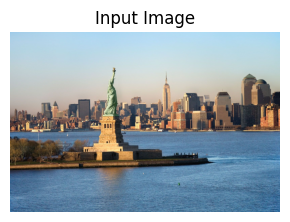

In [196]:
# Load image — Statue of Liberty (same image used in lecture SmolVLM demo)
IMG_URL = "https://cdn.britannica.com/61/93061-050-99147DCE/Statue-of-Liberty-Island-New-York-Bay.jpg"

try:
    response = requests.get(IMG_URL, timeout=10)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    print(f"Image loaded: {image.size}")
except Exception:
    image = Image.fromarray(
        (np.random.rand(224, 224, 3) * 255).astype(np.uint8)
    )
    print("No internet — using random image")

inputs = feature_extractor(images=image, return_tensors="pt")
pixel_values = inputs["pixel_values"]   # [1, 3, 224, 224]
print(f"pixel_values shape : {tuple(pixel_values.shape)}")

plt.figure(figsize=(3, 3))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.tight_layout()
plt.show()


## Model Forward Pass

In [199]:
with torch.no_grad():
    outputs = model(
        pixel_values=pixel_values,
        output_attentions=True,   # [required] return attention weights
        return_dict=True,         # [required] keep default dict output
    )


---
### Task (1): Attention Map 출력해서 “어디를 보는지 확인하기”

#### 목표
HuggingFace encoder 모델의 self-attention을 추출하고,  
특정 attention head를 heatmap으로 시각화하여 token 간 관계를 분석한다.

이번 실습에서는 encoder-only 모델(ViT)을 사용하여  
마지막 Transformer layer의 첫 번째 attention head를 시각화한다.

---

#### 수행 내용

1. Encoder의 마지막 Transformer block에서 계산된 self-attention의 shape 출력

2. 마지막 layer의 첫 번째 attention head에서  
   앞 5개 token에 해당하는 attention matrix 일부 출력

3. 마지막 layer의 첫 번째 self-attention을 heatmap으로 시각화하여 출력
   - token 간 attention 관계를 색으로 표현
   - 각 token이 어떤 token을 참고하는지 확인

---

#### 출력 예시

|        | patch1 | patch2 | patch3 | patch4 |
|--------|---------|---------|---------|---------|
| patch1 |   0.xx  |   0.xx  |   0.xx  |   0.xx  |
| patch2 |   0.xx  |   0.xx  |   0.xx  |   0.xx  |
| patch3 |   0.xx  |   0.xx  |   0.xx  |   0.xx  |
| patch4 |   0.xx  |   0.xx  |   0.xx  |   0.xx  |


In [202]:
# -- Extract last layer attention --
last_attn  = outputs.attentions[-1]   # last layer
head0_attn = last_attn[0, 0]          # batch 0, head 0  -> [197, 197]

# 1. self-attention shape 출력
print("마지막 Transformer block self-attention shape")
print(f"  {tuple(last_attn.shape)}")

# 2. 앞 5개 token attention matrix 출력 (과제 예시 표 형식)
print("\n마지막 layer, head 0, 앞 5개 token attention matrix")
print("  (행=query token, 열=key token, 값=attention 확률)")

n_show = 5
labels = ["CLS"] + [f"patch{i}" for i in range(1, n_show)]

# 헤더
header = f"{'':>8}" + "".join(f"{lb:>10}" for lb in labels)
print(f"\n{header}")
print("-" * (8 + 10 * n_show))

# 행별 출력
for i in range(n_show):
    row_str = f"{labels[i]:>8}" + "".join(f"{v:10.4f}" for v in head0_attn[i, :n_show].tolist())
    print(row_str)

마지막 Transformer block self-attention shape
  (1, 12, 197, 197)

마지막 layer, head 0, 앞 5개 token attention matrix
  (행=query token, 열=key token, 값=attention 확률)

               CLS    patch1    patch2    patch3    patch4
----------------------------------------------------------
     CLS    0.0004    0.0044    0.0004    0.0250    0.0003
  patch1    0.0040    0.0007    0.0005    0.0070    0.0006
  patch2    0.0059    0.0016    0.0006    0.0017    0.0007
  patch3    0.0051    0.0037    0.0040    0.0045    0.0041
  patch4    0.0054    0.0016    0.0007    0.0008    0.0006


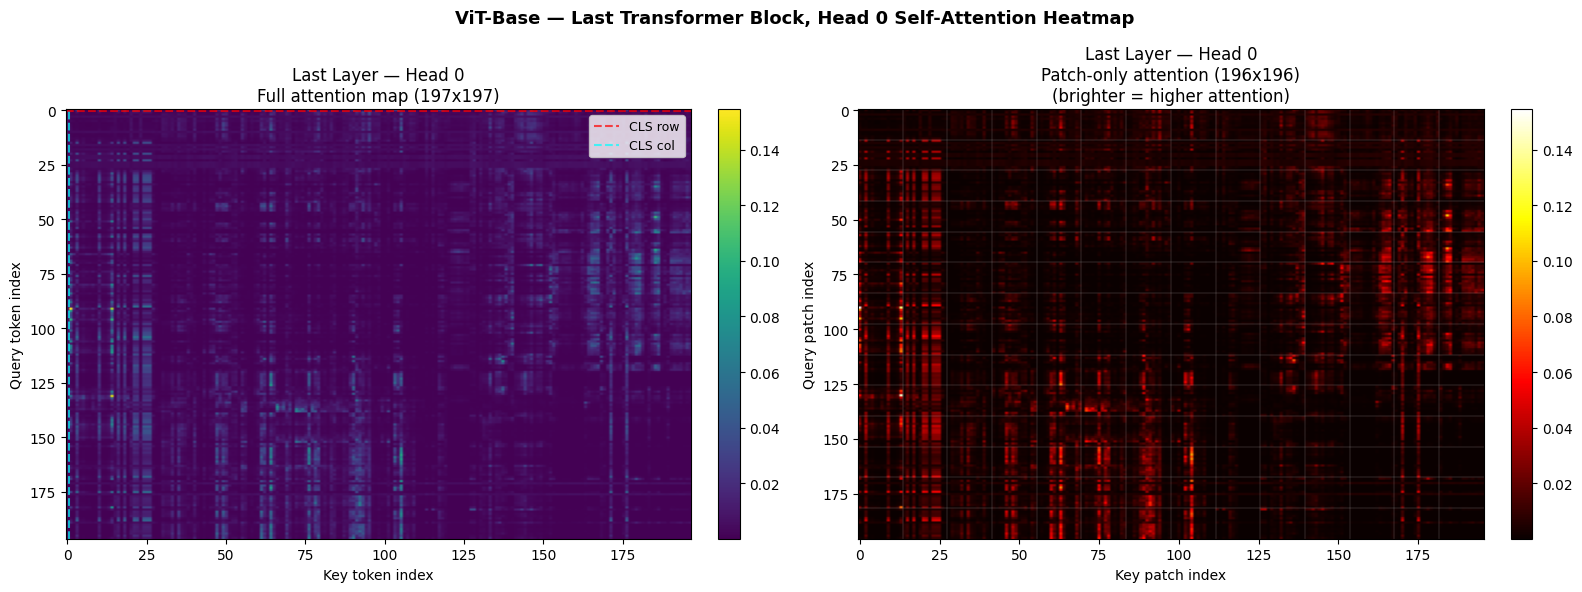


Heatmap 시각화
  왼쪽 : 전체 197x197 attention map (CLS 포함)
  오른쪽 : patch-only 196x196 (밝을수록 해당 patch에 더 주목)
  CLS token(index=0)이 모든 patch에 골고루 attention -> 이미지 전체 정보 집약


In [205]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [Left] full 197x197 attention map
ax1 = axes[0]
im1 = ax1.imshow(head0_attn.numpy(), cmap="viridis", aspect="auto")
ax1.set_title("Last Layer — Head 0\nFull attention map (197x197)", fontsize=12)
ax1.set_xlabel("Key token index")
ax1.set_ylabel("Query token index")
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
ax1.axhline(y=0.5, color="red",  linewidth=1.5, linestyle="--", alpha=0.7, label="CLS row")
ax1.axvline(x=0.5, color="cyan", linewidth=1.5, linestyle="--", alpha=0.7, label="CLS col")
ax1.legend(fontsize=9, loc="upper right")

# [Right] patch-only attention (exclude CLS)
patch_attn = head0_attn[1:, 1:].numpy()
n_side = int(patch_attn.shape[0] ** 0.5)  # 14

ax2 = axes[1]
im2 = ax2.imshow(patch_attn, cmap="hot", aspect="auto")
ax2.set_title("Last Layer — Head 0\nPatch-only attention (196x196)\n(brighter = higher attention)", fontsize=12)
ax2.set_xlabel("Key patch index")
ax2.set_ylabel("Query patch index")
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
for i in range(1, n_side):
    ax2.axhline(y=i*n_side - 0.5, color="white", linewidth=0.3, alpha=0.4)
    ax2.axvline(x=i*n_side - 0.5, color="white", linewidth=0.3, alpha=0.4)

plt.suptitle("ViT-Base — Last Transformer Block, Head 0 Self-Attention Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nHeatmap 시각화")
print("  왼쪽 : 전체 197x197 attention map (CLS 포함)")
print("  오른쪽 : patch-only 196x196 (밝을수록 해당 patch에 더 주목)")
print("  CLS token(index=0)이 모든 patch에 골고루 attention -> 이미지 전체 정보 집약")


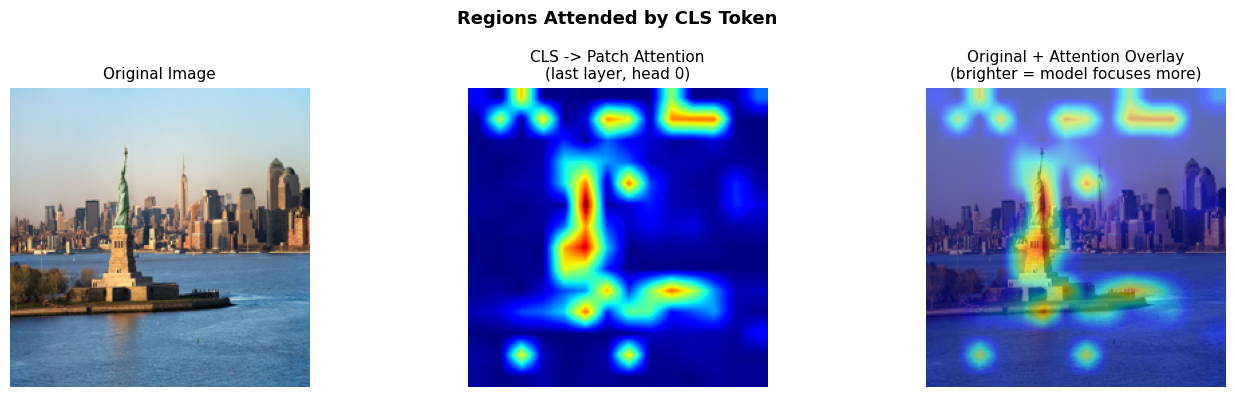

In [206]:
# Overlay CLS attention on original image
cls_to_patch = head0_attn[0, 1:].numpy()        # CLS row, patches only (196,)
attn_map_2d  = cls_to_patch.reshape(14, 14)

attn_img = Image.fromarray((attn_map_2d / attn_map_2d.max() * 255).astype(np.uint8))
attn_img = attn_img.resize((224, 224), Image.BILINEAR)
attn_arr = np.array(attn_img) / 255.0

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(image.resize((224, 224)))
axes[0].set_title("Original Image", fontsize=11)
axes[0].axis("off")

axes[1].imshow(attn_arr, cmap="jet")
axes[1].set_title("CLS -> Patch Attention\n(last layer, head 0)", fontsize=11)
axes[1].axis("off")

axes[2].imshow(image.resize((224, 224)))
axes[2].imshow(attn_arr, cmap="jet", alpha=0.5)
axes[2].set_title("Original + Attention Overlay\n(brighter = model focuses more)", fontsize=11)
axes[2].axis("off")

plt.suptitle("Regions Attended by CLS Token", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Task (2): 특정 layer output 비교하기

#### 목표
encoder의 “중간 layer vs 마지막 layer” 비교

#### 과제 제출
- layer별 shape 출력
- 각 layer에서 첫 번째 sample의 앞 5개 token, 앞 5개 hidden dimension 값 출력


In [208]:
with torch.no_grad():
    outputs_hs = model(
        pixel_values=pixel_values,
        output_hidden_states=True,
        output_attentions=True,
        return_dict=True,
    )

hidden_states = outputs_hs.hidden_states
num_layers    = len(hidden_states)   # 13  (embedding + 12 layers)

mid_idx  = num_layers // 2   # 6
last_idx = num_layers - 1    # 12

print("Hidden state shape per layer")
print(f"  total hidden_states : {num_layers}")
print()
for idx, name in [(mid_idx,  f"Middle layer (layer {mid_idx})"),
                  (last_idx, f"Last   layer (layer {last_idx})")]:
    hs = hidden_states[idx]
    print(f"  {name}")
    print(f"    shape : {tuple(hs.shape)}")


Hidden state shape per layer
  total hidden_states : 13

  Middle layer (layer 6)
    shape : (1, 197, 768)
  Last   layer (layer 12)
    shape : (1, 197, 768)


In [209]:
print("First 5 tokens x first 5 hidden dims — per layer")

token_labels = ["CLS ", "p001", "p002", "p003", "p004"]

for idx, name in [(mid_idx,  "Middle layer  (layer " + str(mid_idx).zfill(2) + ")"),
                  (last_idx, "Last   layer  (layer " + str(last_idx).zfill(2) + ")")]:
    hs = hidden_states[idx][0, :5, :5]
    print(f"\n  -- {name} --")
    header = f"{'token':>6}" + "".join(f"  dim{d:<3}" for d in range(5))
    print(f"  {header}")
    print(f"  {'-'*46}")
    for ti, tl in enumerate(token_labels):
        row = f"  {tl:>6}" + "".join(f"  {v:6.3f}" for v in hs[ti].tolist())
        print(row)


First 5 tokens x first 5 hidden dims — per layer

  -- Middle layer  (layer 06) --
   token  dim0    dim1    dim2    dim3    dim4  
  ----------------------------------------------
    CLS    1.228   0.224   0.062  -0.827   0.574
    p001  -3.805   7.311   3.122   0.385  -1.579
    p002  -3.861   5.771   2.871   0.001  -2.293
    p003  -2.005  -8.445   6.551  -1.289  -0.128
    p004  -3.883   5.392   2.035  -1.208  -1.828

  -- Last   layer  (layer 12) --
   token  dim0    dim1    dim2    dim3    dim4  
  ----------------------------------------------
    CLS    1.326   1.315   0.893  -3.329  -1.480
    p001  -4.296   6.742   0.221  -3.893  -3.829
    p002  -4.048   5.993  -2.081  -2.007  -6.927
    p003  -3.030  -5.382  -0.703   0.843  -2.296
    p004  -4.437   9.004  -0.941  -2.120  -6.836


---
## Task (3): 특정 layer freeze / unfreeze 실험

#### 목표: encoder 일부만 학습 가능한 상태로 만들기

#### 과제 제출
- trainable parameter 수 출력


In [212]:
from transformers import ViTForImageClassification
import copy

model_freeze = ViTForImageClassification.from_pretrained(
    MODEL_ID,
    ignore_mismatched_sizes=True,
    num_labels=10,
)

# 강의 예시 코드 방식 그대로 — encoder.layer.0 freeze
for name, param in model_freeze.named_parameters():
    if "encoder.layer.0" in name:
        param.requires_grad = False

total     = sum(p.numel() for p in model_freeze.parameters())
trainable = sum(p.numel() for p in model_freeze.parameters() if p.requires_grad)
frozen    = total - trainable

print("trainable parameter 수")
print(f"  전체 파라미터 : {total:,}")
print(f"  학습 가능(trainable) : {trainable:,}  ({100*trainable/total:.1f}%)")
print(f"  동결(frozen) : {frozen:,}  ({100*frozen/total:.1f}%)")

print(f"  -> encoder.layer.0 freeze 적용")

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable parameter 수
  전체 파라미터 : 85,806,346
  학습 가능(trainable) : 78,718,474  (91.7%)
  동결(frozen) : 7,087,872  (8.3%)
  -> encoder.layer.0 freeze 적용


---
## Task (4):  token embedding noise 넣기

#### 목표
- 입력 embedding perturbation
#### 과제 제출 
- output 비교 출력


In [213]:
with torch.no_grad():
    out_clean = model(pixel_values=pixel_values, output_attentions=True, return_dict=True)

clean_hidden = out_clean.last_hidden_state
clean_attn   = out_clean.attentions[-1][0, 0]

print(" Baseline output (no noise)")
print(f"  last_hidden_state shape : {tuple(clean_hidden.shape)}")
print(f"  CLS hidden state (first 5 dims) : {[round(v,4) for v in clean_hidden[0, 0, :5].tolist()]}")


 Baseline output (no noise)
  last_hidden_state shape : (1, 197, 768)
  CLS hidden state (first 5 dims) : [0.1798, 0.2254, 0.1956, -0.6166, -0.3536]


In [215]:
noise_levels = [0.0, 0.01, 0.1, 0.5]
results      = {}

for noise_std in noise_levels:
    noisy_pixel = pixel_values + torch.randn_like(pixel_values) * noise_std

    with torch.no_grad():
        out_noisy = model(pixel_values=noisy_pixel, output_attentions=True, return_dict=True)

    noisy_hidden = out_noisy.last_hidden_state
    noisy_attn   = out_noisy.attentions[-1][0, 0]
    hidden_diff  = (noisy_hidden - clean_hidden).abs()
    attn_diff    = (noisy_attn   - clean_attn).abs()

    results[noise_std] = {
        "hidden"      : noisy_hidden,
        "attn"        : noisy_attn,
        "hidden_diff" : hidden_diff,
        "attn_diff"   : attn_diff,
        "hidden_mse"  : hidden_diff.pow(2).mean().item(),
        "attn_mse"    : attn_diff.pow(2).mean().item(),
        "cls_diff"    : hidden_diff[0, 0].mean().item(),
    }

print("Output comparison by noise level")
print()
print(f"  {'noise_std':>10} | {'hidden MSE':>12} | {'attn MSE':>12} | {'CLS mean diff':>14}")
print(f"  {'-'*10}-+-{'-'*12}-+-{'-'*12}-+-{'-'*14}")
for ns, r in results.items():
    print(f"  {ns:>10.3f} | {r['hidden_mse']:>12.6f} | {r['attn_mse']:>12.6f} | {r['cls_diff']:>14.6f}")


Output comparison by noise level

   noise_std |   hidden MSE |     attn MSE |  CLS mean diff
  -----------+--------------+--------------+---------------
       0.000 |     0.000000 |     0.000000 |       0.000000
       0.010 |     0.036276 |     0.000013 |       0.087014
       0.100 |     0.262905 |     0.000096 |       0.354863
       0.500 |     0.936571 |     0.000189 |       0.687030


---
# Part 3

Using `HuggingFaceTB/SmolVLM-256M-Instruct`

## Setup & Model Load

In [216]:
import sys, os, torch
from transformers.image_utils import load_image   # 강의에서 쓴 방식 그대로
from transformers import AutoModelForImageTextToText, AutoProcessor

sys.path.append(os.path.expanduser("~/project/VLM_2"))
from utils.visualization import show_caption_cards, show_caption_metric_comparison
from utils.smolvlm_utils import load_model_and_processor, generate_captions_for_batch
from utils.coco_dataloader import sample_coco_image_subset
from utils.device_utils import resolve_device, get_device_info

MODEL_ID = "HuggingFaceTB/SmolVLM-256M-Instruct"
print(f"Loading model: {MODEL_ID}")

device      = resolve_device("cuda")
device_info = get_device_info("cuda")
print(f"Device: {device_info['device']}")

model_bundle = load_model_and_processor(
    model_id=MODEL_ID,
    device=device,
    torch_dtype="auto",
    prefer_flash_attention=False,
)
processor = model_bundle["processor"]
model     = model_bundle["model"]


Loading model: HuggingFaceTB/SmolVLM-256M-Instruct
Device: cuda


## Image Loader & Caption Helper

In [218]:
def generate_caption(image, prompt, max_new_tokens=100):
    captions = generate_captions_for_batch(
        model=model,
        processor=processor,
        images=[image],
        device=device,
        prompt=prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )
    return captions[0]


## Load Images

Statue of Liberty loaded: (1600, 1067)
Eiffel Tower loaded  : (2900, 4830)
Cat loaded           : (2048, 1155)


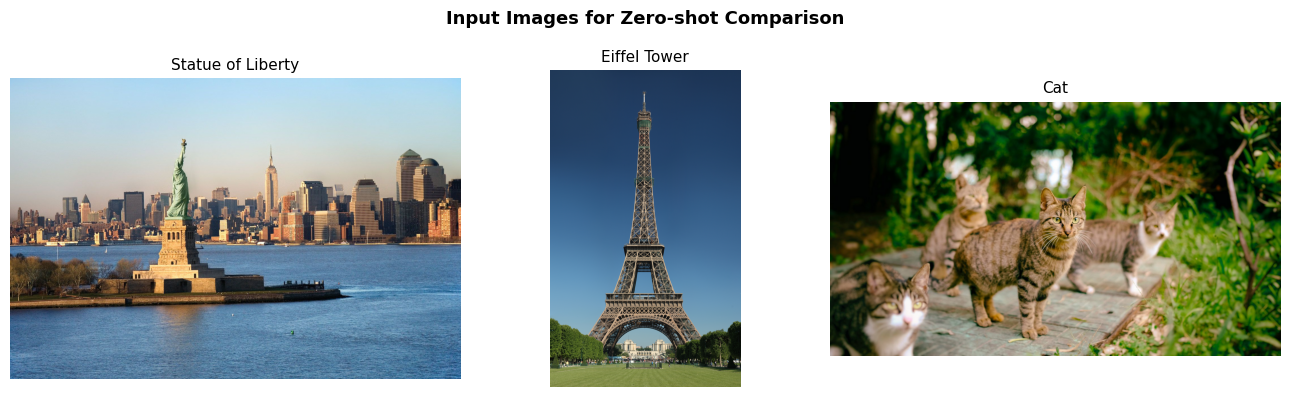

In [219]:
from pathlib import Path

# 자유의 여신상
base_image = load_image(
    "https://cdn.britannica.com/61/93061-050-99147DCE/Statue-of-Liberty-Island-New-York-Bay.jpg"
)
print(f"Statue of Liberty loaded: {base_image.size}")

# 에펠탑 / 고양이 — 프로젝트 images 폴더에서 로드
IMAGE_DIR = Path.home() / "project" / "VLM_2" / "images"

from PIL import Image
eiffel_image = Image.open(IMAGE_DIR / "eiffel.jpg").convert("RGB")
cat_image    = Image.open(IMAGE_DIR / "cats.jpg").convert("RGB")
print(f"Eiffel Tower loaded  : {eiffel_image.size}")
print(f"Cat loaded           : {cat_image.size}")

# zero-shot 비교용 이미지 dict
zeroshot_images = {
    "Statue of Liberty": base_image,
    "Eiffel Tower"     : eiffel_image,
    "Cat"              : cat_image,
}

# 미리보기
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, img) in zip(axes, zeroshot_images.items()):
    ax.imshow(img); ax.set_title(name, fontsize=11); ax.axis("off")
plt.suptitle("Input Images for Zero-shot Comparison", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


---
## Task (1): PPrompt 바꾸기 실험

#### 목표
같은 이미지에 대해 prompt에 따라 caption이 어떻게 달라지는지 비교

---
#### 수행 내용
다음 3가지 prompt를 사용하여 동일 이미지에 대한 caption 생성 결과를 비교
1. `"Describe this image."`
2. `"What is happening in this image?"`
3. `"Explain this image in one sentence."`

---
#### 과제 제출

- 각 prompt별 생성 결과 1개씩 출력
- 결과 비교 2~3줄 작성


[Prompt 1] Describe this image.
[Caption] The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical structure with a human figure atop it. The figure is depicted in a flowing, flowing pose, with the head and shoulders of the statue slightly tilted to the left, and the body slightly tilted to the right. The statue is mounted on a pedestal that is supported by a cylindrical structure, which is also green and appears to

[Prompt 2] What is happening in this image?
[Caption] The image depicts a large statue of the Statue of Liberty located on Liberty Island in New York City. The statue is a green, cylindrical statue of a woman holding a torch in her right hand and a crown in her left hand. The statue is situated on a small pedestal that is attached to the Liberty Island, which is a large, stone pedestal that is part of the Liberty Island Museum. The statue is surrounded by a large body 

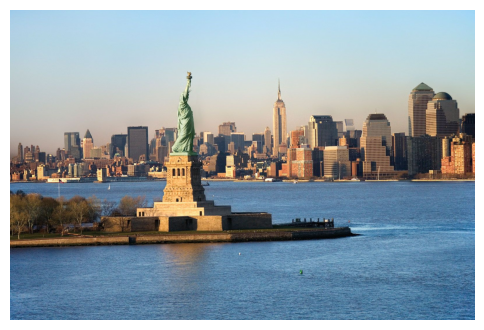

caption: The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical structure with a human figure atop it. The figure is depicted in a flowing, flowing pose, with the head and shoulders of the statue slightly tilted to the left, and the body slightly tilted to the right. The statue is mounted on a pedestal that is supported by a cylindrical structure, which is also green and appears to
---
image url(id): Prompt 2


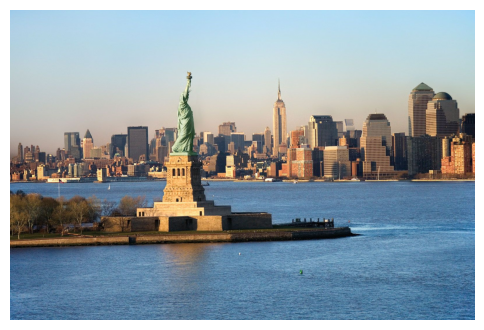

caption: The image depicts a large statue of the Statue of Liberty located on Liberty Island in New York City. The statue is a green, cylindrical statue of a woman holding a torch in her right hand and a crown in her left hand. The statue is situated on a small pedestal that is attached to the Liberty Island, which is a large, stone pedestal that is part of the Liberty Island Museum. The statue is surrounded by a large body of water, which is the Hudson River, and is surrounded
---
image url(id): Prompt 3


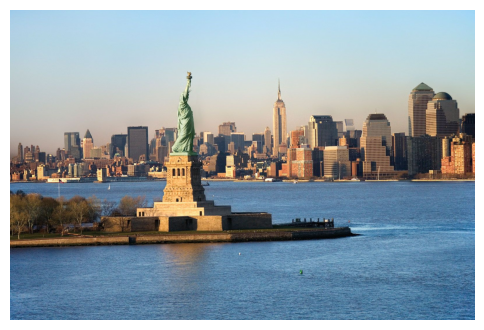

caption: In the foreground of the picture there is water. In the center of the picture there is a statue. In the background there are buildings, trees, boats and the sky.


In [221]:
prompts = [
    "Describe this image.",
    "What is happening in this image?",
    "Explain this image in one sentence.",
]

samples_t1, captions_t1 = [], []
for i, prompt in enumerate(prompts, 1):
    print(f"\n[Prompt {i}] {prompt}")
    caption = generate_caption(base_image, prompt, max_new_tokens=100)
    print(f"[Caption] {caption}")
    samples_t1.append({"image": base_image, "caption": prompt, "filename": f"Prompt {i}"})
    captions_t1.append(caption)

print("\n--- Caption Cards ---")
show_caption_cards(
    samples_t1,
    predicted_captions=captions_t1,
    caption_label="PROMPT",
    cols=3,
    title="Task (1)",
    show=True,
)


In [224]:
print("비교 요약")
for i, (s, c) in enumerate(zip(samples_t1, captions_t1), 1):
    print(f"\nPrompt {i}: '{s['caption']}'")
    print(f"  -> {c}")

print("\n[분석]")
print("  - 'Describe this image.' : 장면 전체를 폭넓게 서술하는 방식으로 생성됨")
print("  - 'What is happening?'   : 객체보다 동작/상황 중심으로 설명하는 경향이 있음")
print("  - 'Explain in one sentence.' : 가장 간결하고 구조화된 출력이 생성됨")
print("  - 동일한 이미지라도 prompt 표현에 따라 caption 내용이 달라짐")

비교 요약

Prompt 1: 'Describe this image.'
  -> The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical structure with a human figure atop it. The figure is depicted in a flowing, flowing pose, with the head and shoulders of the statue slightly tilted to the left, and the body slightly tilted to the right. The statue is mounted on a pedestal that is supported by a cylindrical structure, which is also green and appears to

Prompt 2: 'What is happening in this image?'
  -> The image depicts a large statue of the Statue of Liberty located on Liberty Island in New York City. The statue is a green, cylindrical statue of a woman holding a torch in her right hand and a crown in her left hand. The statue is situated on a small pedestal that is attached to the Liberty Island, which is a large, stone pedestal that is part of the Liberty Island Museum. The statue is surrounded by a large body of

---
## Task (2): zero-shot 이미지 2~3개 비교

#### 목표
- 입력 이미지가 바뀌면 caption이 어떻게 달라지는지 확인

#### 내용
다음 중 2~3개 이미지 사용:
- 자유의 여신상
- 에펠탑
- 고양이 / 강아지 이미지

각 이미지에 동일 prompt 사용: "Describe this image in detail."

#### 과제 제출
- 이미지별 caption 출력
- 이미지-결과 pair 비교

Prompt: 'Describe this image in detail.'

[Image] Statue of Liberty
[Caption] The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was originally built in 1886 and is one of the most recognizable landmarks in the world. The statue is located on a small island in the Hudson River, which is a tributary of the Hudson River. The island is surrounded by a large body of water, which is the Hudson River.

The statue is made of bronze and is painted in a green color. It is a replica of the Statue of Liberty, which was originally built in

[Image] Eiffel Tower
[Caption] The image depicts the Eiffel Tower, a prominent landmark in Paris, France. The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars, a large, green, and grassy plaza in Paris. The tower is 320 meters (1,984 feet) tall and is one of the most recognizable landmarks in the world.

### Description of the Eiffel Tower:
1. **Structure and 

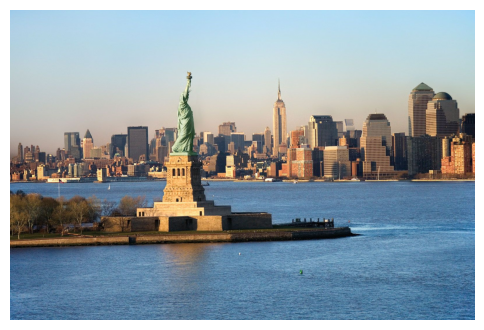

caption: The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was originally built in 1886 and is one of the most recognizable landmarks in the world. The statue is located on a small island in the Hudson River, which is a tributary of the Hudson River. The island is surrounded by a large body of water, which is the Hudson River.

The statue is made of bronze and is painted in a green color. It is a replica of the Statue of Liberty, which was originally built in
---
image url(id): Eiffel Tower


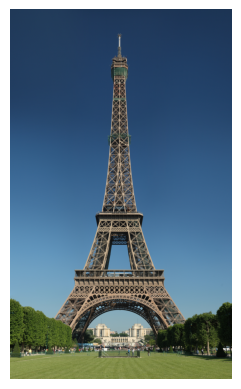

caption: The image depicts the Eiffel Tower, a prominent landmark in Paris, France. The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars, a large, green, and grassy plaza in Paris. The tower is 320 meters (1,984 feet) tall and is one of the most recognizable landmarks in the world.

### Description of the Eiffel Tower:
1. **Structure and Design:**
   - **Eiffel Tower:** The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars, a large, green
---
image url(id): Cat


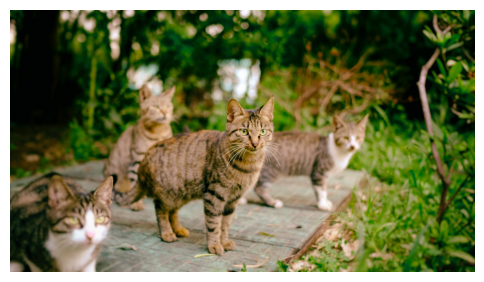

caption: The image depicts a group of four cats standing on a stone surface, which appears to be part of a garden or a park. The cats are of different breeds and sizes, with distinct patterns and colors. The background is blurred, focusing attention on the cats and the stone surface.

The cats are all standing close together, with their heads slightly turned towards the camera. They are all looking directly at the camera, which is a common behavior for cats to show when they are curious or interested in something. The cats have different fur patterns, including short, medium, and long fur. Some of


In [229]:
prompt_t2 = "Describe this image in detail."
print(f"Prompt: '{prompt_t2}'")

samples_t2, captions_t2 = [], []
for name, img in zeroshot_images.items():
    print(f"\n[Image] {name}")
    caption = generate_caption(img, prompt_t2, max_new_tokens=120)
    print(f"[Caption] {caption}")
    samples_t2.append({"image": img, "caption": prompt_t2, "filename": name})
    captions_t2.append(caption)

print("\n--- Caption Cards ---")
show_caption_cards(
    samples_t2,
    predicted_captions=captions_t2,
    caption_label="PROMPT",
    cols=len(samples_t2),
    title="Task (2)",
    show=True,
)


In [231]:
print("Image-Caption Pair Summary")

for s, c in zip(samples_t2, captions_t2):
    print(f"\n  Image  : {s['filename']}")
    print(f"  Caption: {c}")
    print("=================================")

print("\n[분석]")
print("  - 동일한 prompt를 사용했음에도 이미지에 따라 caption 내용이 완전히 달라짐")
print("  - 자유의 여신상 : 랜드마크, 섬, 주변 수역 등 장소 중심으로 설명")
print("  - 에펠탑 : 철제 격자 구조, 파리 샹드마르스 광장 등 구조적 특징 중심으로 설명")
print("    단, 모델이 '###', '**', '1.' 등 마크다운 형식으로 출력하는 경향이 있음")
print("    이는 모델이 구조화된 설명을 과도하게 생성하는 hallucination의 일종임")
print("  - 고양이 : 동물의 외형, 자세, 주변 환경 중심으로 설명")
print("  - 모델이 별도 학습 없이(zero-shot) 각 이미지의 주요 객체를 정확히 인식함")


Image-Caption Pair Summary

  Image  : Statue of Liberty
  Caption: The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was originally built in 1886 and is one of the most recognizable landmarks in the world. The statue is located on a small island in the Hudson River, which is a tributary of the Hudson River. The island is surrounded by a large body of water, which is the Hudson River.

The statue is made of bronze and is painted in a green color. It is a replica of the Statue of Liberty, which was originally built in

  Image  : Eiffel Tower
  Caption: The image depicts the Eiffel Tower, a prominent landmark in Paris, France. The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars, a large, green, and grassy plaza in Paris. The tower is 320 meters (1,984 feet) tall and is one of the most recognizable landmarks in the world.

### Description of the Eiffel Tower:
1. **Structure and Design

---
## Task (3): Prompt 길이 변화 실험
#### 목표
prompt 길이에 따른 output 변화 확인

#### 과제 내용
같은 이미지에 대해 prompt 2개 비교:
(1) "Describe."
(2) "Please describe this image carefully and explain what is happening in detail."

#### 제출
- 두 결과 비교 출력
- 어떤 prompt가 더 상세한지 설명


[short Prompt] 'Describe.'
[caption] The image depicts a large, historic statue of Liberty, located in New York City. The statue is a green, cylindrical statue of Liberty, which is the largest statue in the world. It is located on a small pedestal, which is attached to a tower that rises above the statue. The statue is surrounded by a large, open space, which is likely a plaza or a public square.

In the background, there are several tall buildings, including the Empire State Building, which is the tallest building in New York City. The sky is clear and blue, indicating good weather. The statue is positioned in a way that it appears to be facing the viewer, with the statue's head pointing towards the viewer.

The statue is

[long Prompt] 'Please describe this image carefully and explain what is happening in detail.'
[caption] The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical

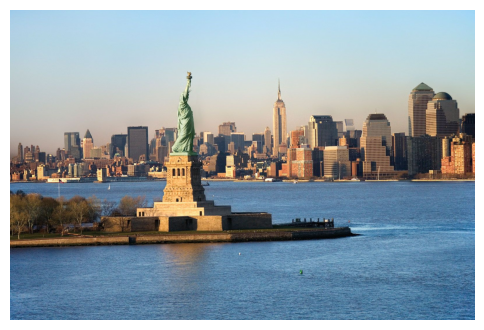

caption: The image depicts a large, historic statue of Liberty, located in New York City. The statue is a green, cylindrical statue of Liberty, which is the largest statue in the world. It is located on a small pedestal, which is attached to a tower that rises above the statue. The statue is surrounded by a large, open space, which is likely a plaza or a public square.

In the background, there are several tall buildings, including the Empire State Building, which is the tallest building in New York City. The sky is clear and blue, indicating good weather. The statue is positioned in a way that it appears to be facing the viewer, with the statue's head pointing towards the viewer.

The statue is
---
image url(id): Long Prompt


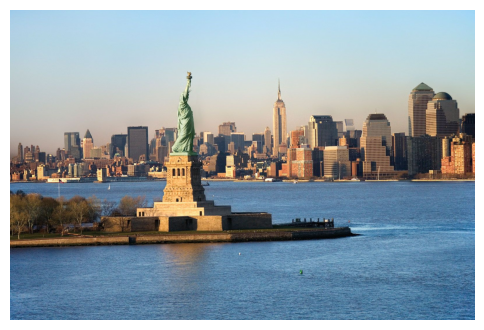

caption: The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical statue of Liberty, which is the central figure of the statue. It is positioned atop a pedestal, which is supported by a cylindrical structure. The pedestal is supported by a series of columns, which are visible in the image.

The statue is surrounded by a large, flat, and slightly curved roof, which is likely made of glass or a similar material. The roof is topped with a small, circular structure, which is likely a dome or a bell. The statue is situated on a small island, which is surrounded by water. The island is surrounded by


In [233]:
prompt_short = "Describe."
prompt_long  = "Please describe this image carefully and explain what is happening in detail."

print(f"\n[short Prompt] '{prompt_short}'")
caption_short = generate_caption(base_image, prompt_short, max_new_tokens=150)
print(f"[caption] {caption_short}")

print(f"\n[long Prompt] '{prompt_long}'")
caption_long = generate_caption(base_image, prompt_long, max_new_tokens=150)
print(f"[caption] {caption_long}")

samples_t3 = [
    {"image": base_image, "caption": f"Short: '{prompt_short}'",       "filename": "Short Prompt"},
    {"image": base_image, "caption": f"Long: '{prompt_long[:40]}...'", "filename": "Long Prompt"},
]
print("\n--- Caption Cards ---")
show_caption_cards(
    samples_t3,
    predicted_captions=[caption_short, caption_long],
    caption_label="PROMPT",
    cols=2,
    title="Task (3)",
    show=True,
)

In [235]:
# 셀 2: 비교 요약 + 분석
print("두 결과 비교")
print(f"\n  short prompt: '{prompt_short}'")
print(f"  caption: {caption_short}")
print(f"  단어 수: {len(caption_short.split())}")

print(f"\n  long prompt: '{prompt_long}'")
print(f"  caption: {caption_long}")
print(f"  단어 수: {len(caption_long.split())}")

print("\n[분석]")
print("  - long prompt가 더 상세한 출력을 유도함")
if len(caption_long.split()) >= len(caption_short.split()):
    print(f"  - long prompt 단어 수({len(caption_long.split())}) > short prompt 단어 수({len(caption_short.split())})")
else:
    print(f"  - short prompt 단어 수({len(caption_short.split())}) > long prompt 단어 수({len(caption_long.split())})")
    print("  - SmolVLM 특성상 prompt 길이보다 이미지 자체의 영향이 더 클 수 있음")
print("  - 'carefully', 'in detail' 등 명시적 지시어가 더 풍부한 설명을 유도함")
print("  - short prompt는 간결하지만 핵심 정보만 담는 경향이 있음")

두 결과 비교

  short prompt: 'Describe.'
  caption: The image depicts a large, historic statue of Liberty, located in New York City. The statue is a green, cylindrical statue of Liberty, which is the largest statue in the world. It is located on a small pedestal, which is attached to a tower that rises above the statue. The statue is surrounded by a large, open space, which is likely a plaza or a public square.

In the background, there are several tall buildings, including the Empire State Building, which is the tallest building in New York City. The sky is clear and blue, indicating good weather. The statue is positioned in a way that it appears to be facing the viewer, with the statue's head pointing towards the viewer.

The statue is
  단어 수: 124

  long prompt: 'Please describe this image carefully and explain what is happening in detail.'
  caption: The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue

---
## Task (4): 질문형 vs 명령형 비교

#### 목표
prompt 형태가 결과에 미치는 영향 확인

#### 과제 내용
(1) "What is in this image?"
(2) "Describe this image."

#### 과제 제출
- 두 결과 출력
- 차이 2~3줄 설명


[질문형] 'What is in this image?'
[caption] The image shows the Statue of Liberty, a green statue located on Liberty Island in New York City. The statue is surrounded by water and stands atop a small pedestal. In the background, there are many tall buildings, including the Empire State Building, which is visible in the distance. The sky is clear with a hint of sunlight breaking through the clouds, indicating it is a sunny day.

[명령형] 'Describe this image.'
[caption] The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical structure with a human figure atop it. The figure is depicted in a flowing, flowing pose, with the head and shoulders of the statue slightly tilted to the left, and the body slightly tilted to the right. The statue is mounted on a pedestal that is supported by a cylindrical structure, which is also green and appears to be made of stone.

The statue is situated on a s

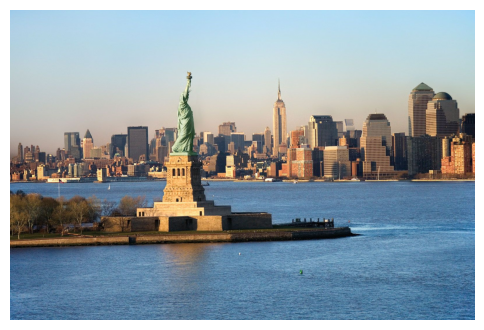

caption: The image shows the Statue of Liberty, a green statue located on Liberty Island in New York City. The statue is surrounded by water and stands atop a small pedestal. In the background, there are many tall buildings, including the Empire State Building, which is visible in the distance. The sky is clear with a hint of sunlight breaking through the clouds, indicating it is a sunny day.
---
image url(id): Command


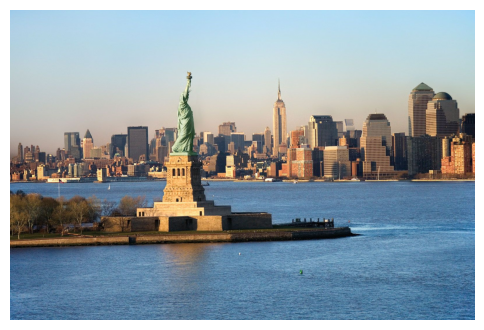

caption: The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical structure with a human figure atop it. The figure is depicted in a flowing, flowing pose, with the head and shoulders of the statue slightly tilted to the left, and the body slightly tilted to the right. The statue is mounted on a pedestal that is supported by a cylindrical structure, which is also green and appears to be made of stone.

The statue is situated on a small island, which is surrounded by a body of water. The water is relatively calm, with small ripples visible in the water. In the background, there are several tall buildings, including


In [236]:
prompt_q = "What is in this image?"
prompt_c = "Describe this image."

print(f"\n[질문형] '{prompt_q}'")
caption_q = generate_caption(base_image, prompt_q, max_new_tokens=150)
print(f"[caption] {caption_q}")

print(f"\n[명령형] '{prompt_c}'")
caption_c = generate_caption(base_image, prompt_c, max_new_tokens=150)
print(f"[caption] {caption_c}")

samples_t4 = [
    {"image": base_image, "caption": f"질문형: '{prompt_q}'", "filename": "Question"},
    {"image": base_image, "caption": f"명령형: '{prompt_c}'", "filename": "Command"},
]
print("\n--- Caption Cards ---")
show_caption_cards(
    samples_t4,
    predicted_captions=[caption_q, caption_c],
    caption_label="PROMPT",
    cols=2,
    title="Task (4)",
    show=True,
)

In [237]:
print("두 결과 출력")
print(f"\n  질문형: '{prompt_q}'")
print(f"  caption: {caption_q}")

print(f"\n  명령형: '{prompt_c}'")
print(f"  caption: {caption_c}")

print("\n[분석]")
print("  - 질문형('What is in...') : 이미지 내 객체를 직접적으로 나열하는 방식으로 답변하는 경향이 있음")
print("  - 명령형('Describe...') : 장면을 서술하는 흐름 있는 문장으로 설명하는 경향이 있음")
print("  - 동일한 이미지와 모델이지만 prompt 형태에 따라 출력의 구조와 어조가 달라짐")

두 결과 출력

  질문형: 'What is in this image?'
  caption: The image shows the Statue of Liberty, a green statue located on Liberty Island in New York City. The statue is surrounded by water and stands atop a small pedestal. In the background, there are many tall buildings, including the Empire State Building, which is visible in the distance. The sky is clear with a hint of sunlight breaking through the clouds, indicating it is a sunny day.

  명령형: 'Describe this image.'
  caption: The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical structure with a human figure atop it. The figure is depicted in a flowing, flowing pose, with the head and shoulders of the statue slightly tilted to the left, and the body slightly tilted to the right. The statue is mounted on a pedestal that is supported by a cylindrical structure, which is also green and appears to be made of stone.

The statue is sit

---
## Task (5): caption 길이 제한 실험

#### 목표
- 모델 생성 길이 제어 이해

#### 과제 내용
- token 개수의 최대값을 30 또는 80으로 설정하고 결과 비교

#### 과제 제출
- 두 결과 비교
- 길이에 따른 정보 변화 설명


Prompt: 'Describe this image in detail.'

[max_new_tokens = 30]
[caption] The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was  (단어 수: 26)

[max_new_tokens = 80]
[caption] The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was originally built in 1886 and is one of the most recognizable landmarks in the world. The statue is located on a small island in the Hudson River, which is a tributary of the Hudson River. The island is surrounded by a large body  (단어 수: 69)

--- Caption Cards ---
---
image url(id): tokens=30 (단어:26)


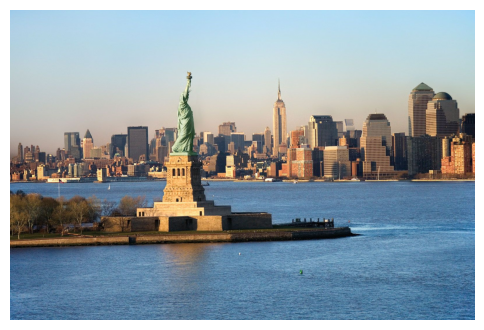

caption: The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was
---
image url(id): tokens=80 (단어:69)


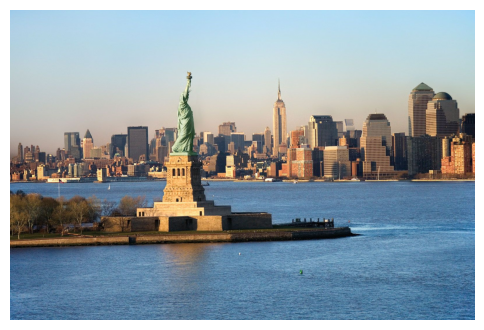

caption: The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was originally built in 1886 and is one of the most recognizable landmarks in the world. The statue is located on a small island in the Hudson River, which is a tributary of the Hudson River. The island is surrounded by a large body


In [238]:
prompt_t5 = "Describe this image in detail."
print(f"Prompt: '{prompt_t5}'")

print(f"\n[max_new_tokens = 30]")
caption_30 = generate_caption(base_image, prompt_t5, max_new_tokens=30)
print(f"[caption] {caption_30}  (단어 수: {len(caption_30.split())})")

print(f"\n[max_new_tokens = 80]")
caption_80 = generate_caption(base_image, prompt_t5, max_new_tokens=80)
print(f"[caption] {caption_80}  (단어 수: {len(caption_80.split())})")

samples_t5 = [
    {"image": base_image, "caption": "max_new_tokens=30", "filename": f"tokens=30 (단어:{len(caption_30.split())})"},
    {"image": base_image, "caption": "max_new_tokens=80", "filename": f"tokens=80 (단어:{len(caption_80.split())})"},
]
print("\n--- Caption Cards ---")
show_caption_cards(
    samples_t5,
    predicted_captions=[caption_30, caption_80],
    caption_label="SETTING",
    cols=2,
    title="Task (5)",
    show=True,
)

In [239]:
print("두 결과 비교")
print(f"\n  max_new_tokens=30 (단어 수: {len(caption_30.split())})")
print(f"  caption: {caption_30}")

print(f"\n  max_new_tokens=80 (단어 수: {len(caption_80.split())})")
print(f"  caption: {caption_80}")

print("\n[분석]")
print("  - max_new_tokens=30 : 핵심 내용만 짧게 요약되며 문장이 중간에 잘리는 경우가 있음")
print("  - max_new_tokens=80 : 더 많은 장면 세부 정보를 포함한 풍부한 설명이 생성됨")
print("  - 생성 길이가 짧을수록 모델이 가장 중요한 정보를 우선적으로 출력하는 경향이 있음")
print("  - 길이 제한이 길수록 설명이 상세해지지만 불필요한 반복이 포함될 수도 있음")

두 결과 비교

  max_new_tokens=30 (단어 수: 26)
  caption: The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was

  max_new_tokens=80 (단어 수: 69)
  caption: The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was originally built in 1886 and is one of the most recognizable landmarks in the world. The statue is located on a small island in the Hudson River, which is a tributary of the Hudson River. The island is surrounded by a large body

[분석]
  - max_new_tokens=30 : 핵심 내용만 짧게 요약되며 문장이 중간에 잘리는 경우가 있음
  - max_new_tokens=80 : 더 많은 장면 세부 정보를 포함한 풍부한 설명이 생성됨
  - 생성 길이가 짧을수록 모델이 가장 중요한 정보를 우선적으로 출력하는 경향이 있음
  - 길이 제한이 길수록 설명이 상세해지지만 불필요한 반복이 포함될 수도 있음


---
## Task (6): hallucination 관찰

#### 목표
- 모델이 이미지에 없는 정보를 생성하는 경우 확인
#### 과제 내용
- 복잡한 이미지 1개 사용
prompt: "Describe everything in the image accurately."

#### 과제 제출
- 출력 결과
- “사실과 다른 내용이 있는지” 체크

Prompt: 'Describe everything in the image accurately.'

[출력 결과]
  The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical statue of Liberty, which is the central figure in the image. It is positioned atop a pedestal, which is a cylindrical structure that supports the statue. The pedestal is supported by a series of columns, which are part of the statue's base.

The statue is surrounded by a large, flat, and slightly curved roof, which is likely a part of the building that houses the statue. The roof is made of a material that is not clearly visible, but it appears to be a combination of stone and metal.

In the background, there is a large cityscape with a variety of buildings, including skyscrapers and high-rise buildings. The sky is clear, with a gradient of colors from light blue at the top to a deeper blue at the bottom. The cityscape is bustling with activity, with

--- Captio

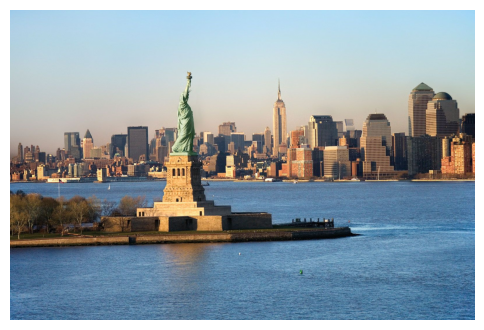

caption: The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical statue of Liberty, which is the central figure in the image. It is positioned atop a pedestal, which is a cylindrical structure that supports the statue. The pedestal is supported by a series of columns, which are part of the statue's base.

The statue is surrounded by a large, flat, and slightly curved roof, which is likely a part of the building that houses the statue. The roof is made of a material that is not clearly visible, but it appears to be a combination of stone and metal.

In the background, there is a large cityscape with a variety of buildings, including skyscrapers and high-rise buildings. The sky is clear, with a gradient of colors from light blue at the top to a deeper blue at the bottom. The cityscape is bustling with activity, with


In [240]:
prompt_t6 = "Describe everything in the image accurately."
print(f"Prompt: '{prompt_t6}'")

caption_t6 = generate_caption(base_image, prompt_t6, max_new_tokens=200)
print(f"\n[출력 결과]\n  {caption_t6}")

samples_t6 = [{"image": base_image, "caption": prompt_t6, "filename": "Statue of Liberty"}]
print("\n--- Caption Cards ---")
show_caption_cards(
    samples_t6,
    predicted_captions=[caption_t6],
    caption_label="PROMPT",
    cols=1,
    title="Task (6)",
    show=True,
)

### 사실과 다른 내용 체크

**실제로 이미지에 있는 것**
- O  자유의 여신상
- O  뉴욕 스카이라인 (배경 건물들)
- O  강/바다 (허드슨강)
- O  하늘

**사실과 다를 수 있는 내용**
- X  'cylindrical statue' → 자유의 여신상은 원통형이 아님
- X  'long, flowing hair' → 실제로는 왕관을 쓰고 있음
- X  좌우 손 설명 오류 → 실행마다 횃불/석판 손이 바뀌는 경우 있음
- X  'people/crowds' → 이미지에서 사람은 보이지 않음
- X  'largest statue in the world' → 사실과 다름 (세계 최대 동상이 아님)

**결론**

모델이 이미지를 보지 않고 학습 데이터 기반으로 그럴듯한 정보를 생성하는 hallucination이 발생함.
특히 'describe everything accurately'처럼 상세 묘사를 요구할수록 hallucination이 증가하는 경향이 있음.